In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

---
# Bài 1: Tập dữ liệu `car_crashes.csv`

In [2]:
df_cars = pd.read_csv('dataset/car_crashes.csv')
print(df_cars.shape)
df_cars.head()

(51, 8)


,total,speeding,alcohol,not_distracted,no_previous,ins_premium,ins_losses,abbrev
0,18.8,7.332,5.640,18.048,15.040,784.55,145.08,AL
1,18.1,7.421,4.525,16.290,17.014,1053.48,133.93,AK
2,18.6,6.510,5.208,15.624,17.856,899.47,110.35,AZ
3,22.4,4.032,5.824,21.056,21.280,827.34,142.39,AR
4,12.0,4.200,3.360,10.920,10.680,878.41,165.63,CA


## 1.1 Boxplot tổng thể các biến số

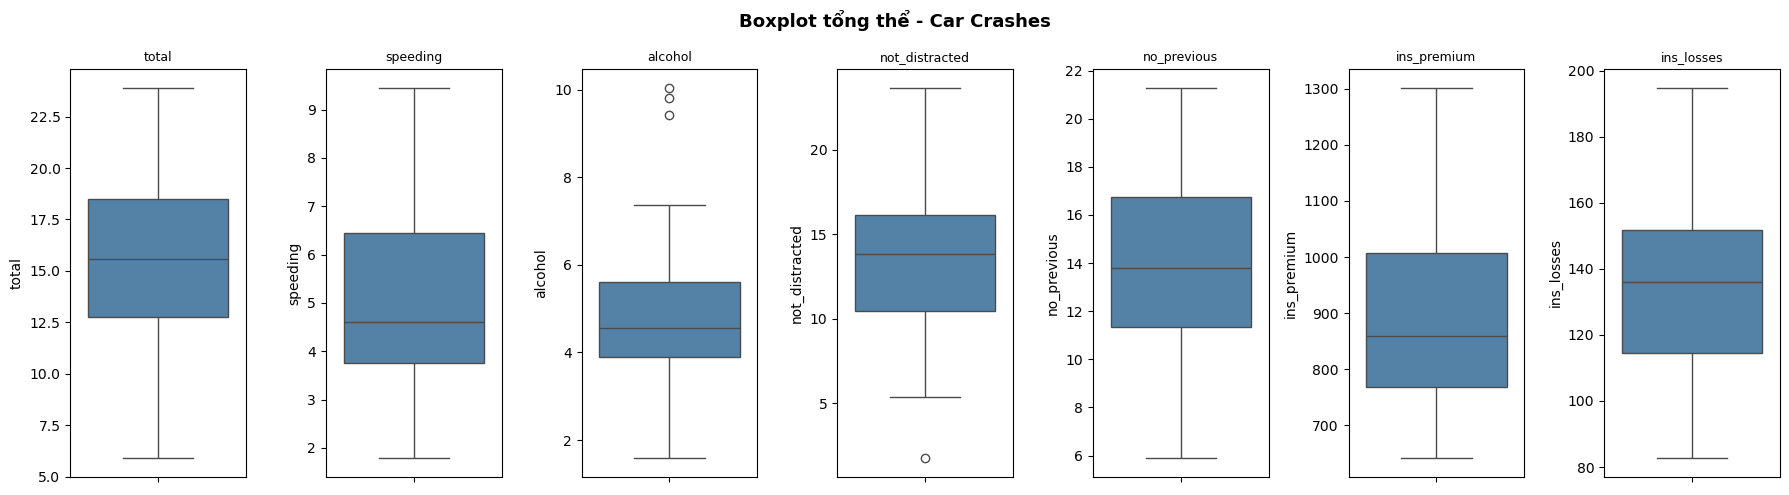

In [3]:

numeric_cols = ['total', 'speeding', 'alcohol', 'not_distracted', 'no_previous', 'ins_premium', 'ins_losses']

fig, axes = plt.subplots(1, len(numeric_cols), figsize=(18, 5))

for i, col in enumerate(numeric_cols):
    sns.boxplot(y=df_cars[col], ax=axes[i], color='steelblue')
    axes[i].set_title(col, fontsize=9)

plt.suptitle('Boxplot tổng thể - Car Crashes', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 1.2 Boxplot từng biến riêng lẻ (chi tiết hơn)

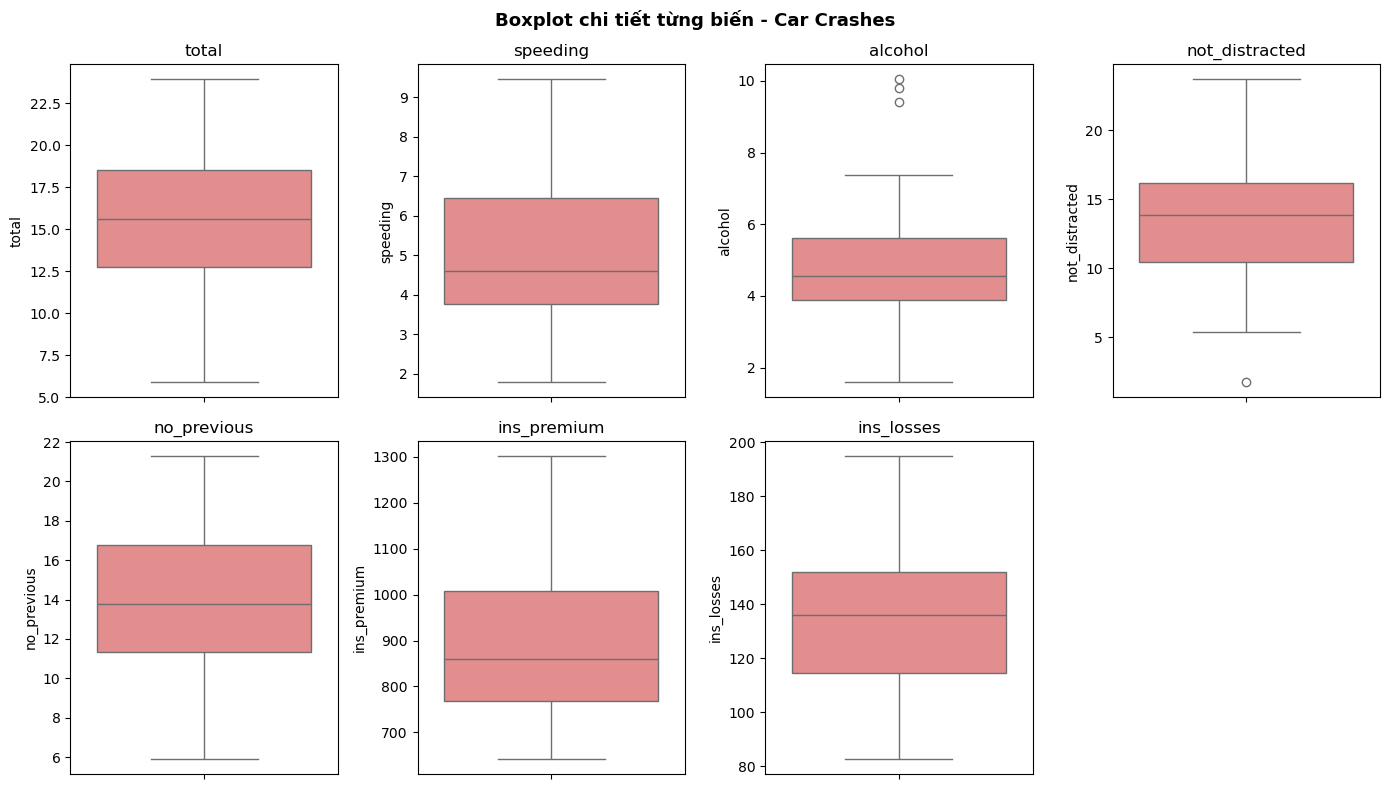

In [4]:
fig, axes = plt.subplots(2, 4, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(y=df_cars[col], ax=axes[i], color='lightcoral')
    axes[i].set_title(col)


axes[-1].set_visible(False)

plt.suptitle('Boxplot chi tiết từng biến - Car Crashes', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Đánh giá Bài 1 - Car Crashes

### `total` (tổng số tai nạn / tỷ lệ tai nạn):
- Phân bố lệch phải nhẹ, median nằm gần giữa hộp.
- Có một vài outlier ở phía trên → một số tiểu bang có tỷ lệ tai nạn rất cao.

### `speeding` (tai nạn do tốc độ):
- IQR tương đối hẹp, dữ liệu tập trung. Có outlier cao phía trên.

### `alcohol` (tai nạn liên quan rượu bia):
- Phân bố lệch phải, median thấp hơn trung bình → đa số tiểu bang có mức thấp, nhưng một số bang có giá trị rất cao.

### `not_distracted` (không bị mất tập trung):
- IQR rộng, dữ liệu phân tán, có outlier cao → biến động lớn giữa các tiểu bang.

### `no_previous` (không có tiền sử tai nạn):
- Phân bố khá đối xứng, ít outlier → dữ liệu tương đối đồng đều giữa các bang.

### `ins_premium` (phí bảo hiểm):
- IQR rộng, phân bố lệch phải mạnh → chênh lệch phí bảo hiểm lớn giữa các bang. Có outlier cao.

### `ins_losses` (tổn thất bảo hiểm):
- Phân bố tương đối đều, IQR vừa phải, ít outlier.

---
# Bài 2: Tập dữ liệu `10_OneNumSevCatSubgroupsSevObs.csv`

In [6]:
df = pd.read_csv('dataset/10_OneNumSevCatSubgroupsSevObs.csv')
print(df.shape)
df.head()

(244, 7)


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


## 2.1 Boxplot total_bill theo nhóm `sex`

C:\Users\Minh Doan\AppData\Local\Temp\ipykernel_15816\3626065041.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='sex', y='total_bill', palette='Set2')


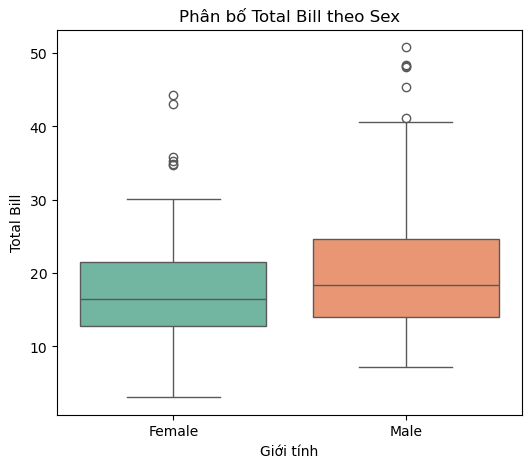

In [7]:
plt.figure(figsize=(6, 5))
sns.boxplot(data=df, x='sex', y='total_bill', palette='Set2')
plt.title('Phân bố Total Bill theo Sex')
plt.xlabel('Giới tính')
plt.ylabel('Total Bill')
plt.show()

### Nhận xét theo `sex`:
- **Male** có median và IQR cao hơn **Female** → nam giới có xu hướng chi tiêu nhiều hơn.
- Cả hai nhóm đều có outlier phía trên → một số hóa đơn rất lớn ở cả hai giới.
- **Male** có phân phối lệch phải mạnh hơn, dữ liệu phân tán rộng hơn.

## 2.2 Boxplot total_bill theo nhóm `smoker`

C:\Users\Minh Doan\AppData\Local\Temp\ipykernel_15816\370504448.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='smoker', y='total_bill', palette='Set1')


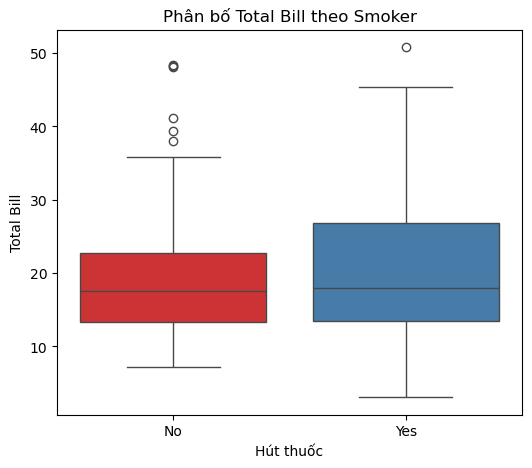

In [8]:
plt.figure(figsize=(6, 5))
sns.boxplot(data=df, x='smoker', y='total_bill', palette='Set1')
plt.title('Phân bố Total Bill theo Smoker')
plt.xlabel('Hút thuốc')
plt.ylabel('Total Bill')
plt.show()

### Nhận xét theo `smoker`:
- Median của **Yes** (hút thuốc) và **No** (không hút thuốc) khá tương đồng → hút thuốc không ảnh hưởng lớn đến tổng hóa đơn.
- **Yes** có IQR rộng hơn → người hút thuốc chi tiêu biến động nhiều hơn.
- Cả hai nhóm đều có outlier cao, nhưng **No** có outlier nhiều hơn.

## 2.3 Boxplot total_bill theo nhóm `time`

C:\Users\Minh Doan\AppData\Local\Temp\ipykernel_15816\343524673.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='time', y='total_bill', palette='Pastel1')


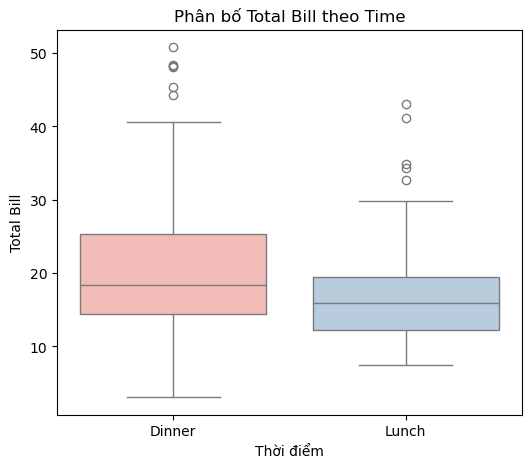

In [9]:
plt.figure(figsize=(6, 5))
sns.boxplot(data=df, x='time', y='total_bill', palette='Pastel1')
plt.title('Phân bố Total Bill theo Time')
plt.xlabel('Thời điểm')
plt.ylabel('Total Bill')
plt.show()

### Nhận xét theo `time`:
- **Dinner** có median và IQR cao hơn rõ rệt so với **Lunch** → bữa tối có hóa đơn lớn hơn bữa trưa.
- **Dinner** cũng có nhiều outlier cao hơn → một số bữa tối rất đắt tiền.
- **Lunch** phân bố tập trung hơn, ít biến động.

## 2.4 Boxplot total_bill theo nhóm `smoker` và `sex`

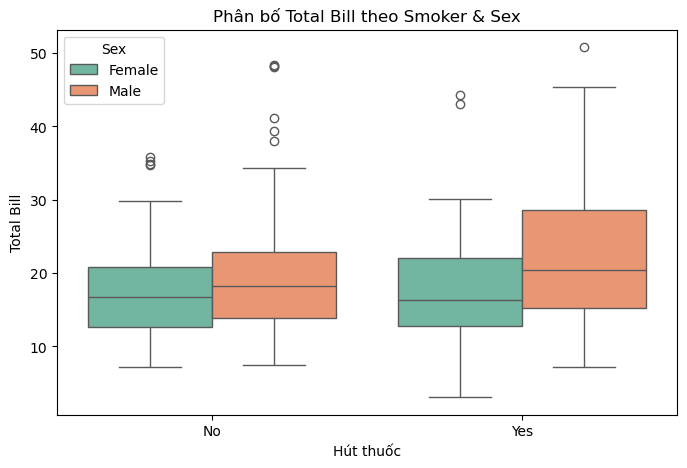

In [10]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='smoker', y='total_bill', hue='sex', palette='Set2')
plt.title('Phân bố Total Bill theo Smoker & Sex')
plt.xlabel('Hút thuốc')
plt.ylabel('Total Bill')
plt.legend(title='Sex')
plt.show()

### Nhận xét theo `smoker` & `sex`:
- **Male hút thuốc (Yes/Male)** có median cao nhất và IQR rộng nhất → nhóm chi tiêu nhiều và biến động nhất.
- **Female không hút thuốc (No/Female)** có median thấp nhất và phân bố tập trung nhất.
- Trong cả hai nhóm smoker/non-smoker, **Male** đều chi tiêu nhiều hơn **Female**.
- **Female hút thuốc (Yes/Female)** có outlier cao bất thường → có một số trường hợp ngoại lệ chi tiêu rất lớn.

## 2.5 Boxplot total_bill theo nhóm `smoker` và `time`

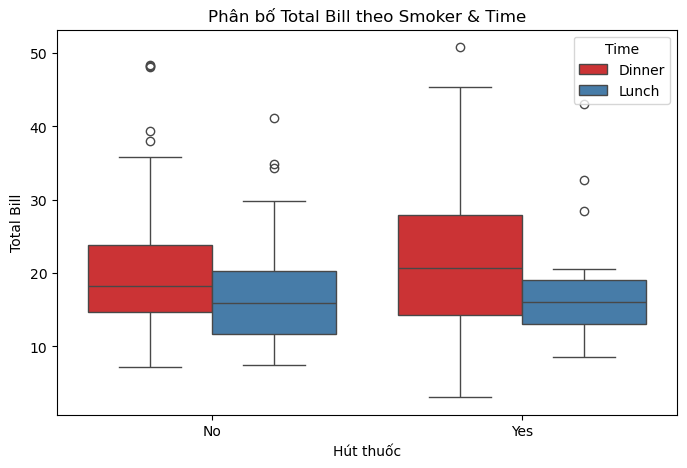

In [11]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='smoker', y='total_bill', hue='time', palette='Set1')
plt.title('Phân bố Total Bill theo Smoker & Time')
plt.xlabel('Hút thuốc')
plt.ylabel('Total Bill')
plt.legend(title='Time')
plt.show()

### Nhận xét theo `smoker` & `time`:
- **Dinner** luôn có median và IQR cao hơn **Lunch** trong cả hai nhóm smoker → thời điểm ăn ảnh hưởng rõ rệt đến tổng hóa đơn hơn là việc hút thuốc.
- **Dinner/Smoker Yes** có IQR rộng nhất và nhiều outlier → nhóm có hóa đơn biến động mạnh nhất.
- **Lunch/Smoker No** có phân bố hẹp và tập trung → nhóm chi tiêu ổn định và thấp nhất.
- Sự khác biệt giữa smoker và non-smoker trong cùng time slot không quá lớn → `time` là yếu tố ảnh hưởng mạnh hơn `smoker`.